# Collector Blackouts

Estimates data lost during collector poll gaps.

In [1]:
from pathlib import Path
import importlib.util
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "analysis"))

spec = importlib.util.spec_from_file_location(
    "collector_blackouts",
    PROJECT_ROOT / "analysis" / "collector-blackouts.py",
)
collector_blackouts = importlib.util.module_from_spec(spec)
spec.loader.exec_module(collector_blackouts)

DB = PROJECT_ROOT / "data" / "foli.db"
LIMIT = 20

In [2]:
class Args:
    db = DB

polls = collector_blackouts.load_polls(Args)
summary = collector_blackouts.summarize_blackouts(polls, LIMIT)
summary

,source,poll_count,success_count,failed_count,expected_cadence_seconds,blackout_count,total_blackout_min,largest_blackout_min,estimated_missed_polls,estimated_missed_rows
2,siri_vm,42556,42454,102,30.0,25,216.22,47.77,432.43,57521.45
1,siri_alerts,4310,4297,13,300.0,3,55.43,34.15,11.09,144.57
0,gtfs,3,3,0,604808.0,0,0.00,0.00,0.00,0.00


Text(0, 0.5, 'Source')

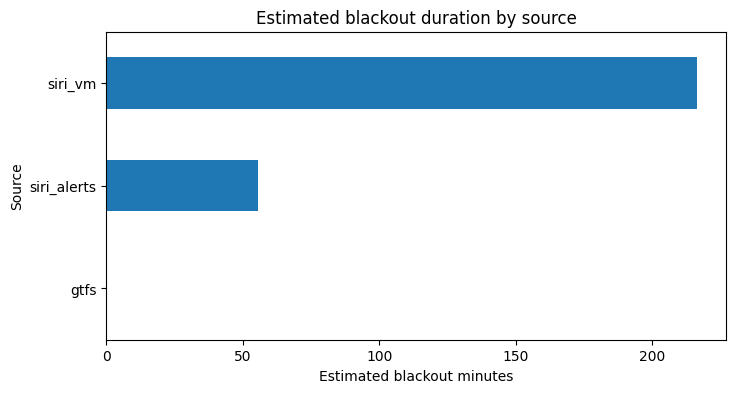

In [3]:
ax = summary.sort_values("total_blackout_min").plot.barh(
    x="source",
    y="total_blackout_min",
    legend=False,
    figsize=(8, 4),
    title="Estimated blackout duration by source",
)
ax.set_xlabel("Estimated blackout minutes")
ax.set_ylabel("Source")